# CO5420 Air Pollution Forecasting

## 01 — Dataset Audit and Exploratory Data Analysis

### Objectives

This notebook:

1. verifies the temporal and station structure of the training dataset;
2. examines missing values and feature distributions;
3. studies PM2.5 patterns across stations and time;
4. investigates relationships between numerical variables;
5. defines a leakage-safe chronological train-validation-local-test split;
6. records preprocessing decisions for the next project stage.

No imputation, feature scaling, or model training is performed in this notebook.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Make imports work whether the notebook is executed from the repository
# root or from inside the notebooks directory.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR,
    METRICS_DIR,
    POLLUTANT_COLUMNS,
    STATION_COLUMN,
    TARGET_COLUMN,
    TIME_COLUMNS,
    TRAIN_RAW_PATH,
    WEATHER_COLUMNS,
)


FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Training file: {TRAIN_RAW_PATH}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Metrics directory: {METRICS_DIR}")

Project root: C:\Users\wijer\Documents\GitHub\co-5420-air-pollution
Training file: C:\Users\wijer\Documents\GitHub\co-5420-air-pollution\data\raw\train_raw.csv
Figures directory: C:\Users\wijer\Documents\GitHub\co-5420-air-pollution\results\figures
Metrics directory: C:\Users\wijer\Documents\GitHub\co-5420-air-pollution\results\metrics


In [2]:
train_raw = pd.read_csv(TRAIN_RAW_PATH, low_memory=False)

print(f"Raw shape: {train_raw.shape}")
display(train_raw.head())

Raw shape: (315648, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.000,4.000,4.000,7.000,300.000,77.000,-0.700,"1,023.000",-18.800,0.000,NNW,4.400,Aotizhongxin
1,2,2013,3,1,1,8.000,8.000,4.000,7.000,300.000,77.000,-1.100,"1,023.200",-18.200,0.000,N,4.700,Aotizhongxin
2,3,2013,3,1,2,7.000,7.000,5.000,10.000,300.000,73.000,-1.100,"1,023.500",-18.200,0.000,NNW,5.600,Aotizhongxin
3,4,2013,3,1,3,6.000,6.000,11.000,11.000,300.000,72.000,-1.400,"1,024.500",-19.400,0.000,NW,3.100,Aotizhongxin
4,5,2013,3,1,4,3.000,3.000,12.000,12.000,300.000,72.000,-2.000,"1,025.200",-19.500,0.000,N,2.000,Aotizhongxin


In [3]:
EXPECTED_COLUMNS = [
    "No",
    "year",
    "month",
    "day",
    "hour",
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "wd",
    "WSPM",
    "station",
]

assert train_raw.shape == (315_648, 18)
assert train_raw.columns.tolist() == EXPECTED_COLUMNS
assert train_raw[STATION_COLUMN].nunique() == 12

print("Raw training-data contract verified.")

Raw training-data contract verified.


In [4]:
train = train_raw.copy()

train["datetime"] = pd.to_datetime(
    train[TIME_COLUMNS],
    errors="raise",
)

train = (
    train
    .sort_values([STATION_COLUMN, "datetime"])
    .reset_index(drop=True)
)

print(f"Start datetime: {train['datetime'].min()}")
print(f"End datetime:   {train['datetime'].max()}")
print(f"Stations:       {train[STATION_COLUMN].nunique()}")

Start datetime: 2013-03-01 00:00:00
End datetime:   2016-02-29 23:00:00
Stations:       12


In [5]:
duplicate_mask = train.duplicated(
    subset=[STATION_COLUMN, "datetime"],
    keep=False,
)

duplicate_count = int(duplicate_mask.sum())

print(f"Duplicate station-timestamp rows: {duplicate_count}")

if duplicate_count > 0:
    display(
        train.loc[
            duplicate_mask,
            [STATION_COLUMN, "datetime"],
        ].head(20)
    )

assert duplicate_count == 0

Duplicate station-timestamp rows: 0


In [6]:
continuity_records = []

for station, station_data in train.groupby(
    STATION_COLUMN,
    sort=True,
):
    station_data = station_data.sort_values("datetime")

    time_differences = (
        station_data["datetime"]
        .diff()
        .dropna()
    )

    non_hourly_intervals = int(
        (
            time_differences
            != pd.Timedelta(hours=1)
        ).sum()
    )

    expected_rows = int(
        (
            station_data["datetime"].max()
            - station_data["datetime"].min()
        )
        / pd.Timedelta(hours=1)
    ) + 1

    continuity_records.append(
        {
            "station": station,
            "actual_rows": len(station_data),
            "expected_rows": expected_rows,
            "missing_timestamps": expected_rows - len(station_data),
            "non_hourly_intervals": non_hourly_intervals,
            "start_datetime": station_data["datetime"].min(),
            "end_datetime": station_data["datetime"].max(),
        }
    )

continuity_summary = pd.DataFrame(continuity_records)

display(continuity_summary)

assert continuity_summary["missing_timestamps"].sum() == 0
assert continuity_summary["non_hourly_intervals"].sum() == 0

,station,actual_rows,expected_rows,missing_timestamps,non_hourly_intervals,start_datetime,end_datetime
0,Aotizhongxin,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
1,Changping,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
2,Dingling,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
3,Dongsi,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
4,Guanyuan,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
5,Gucheng,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
6,Huairou,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
7,Nongzhanguan,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
8,Shunyi,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00
9,Tiantan,26304,26304,0,0,2013-03-01,2016-02-29 23:00:00


In [7]:
column_summary = pd.DataFrame(
    {
        "dtype": train_raw.dtypes.astype(str),
        "non_null_count": train_raw.notna().sum(),
        "missing_count": train_raw.isna().sum(),
        "unique_values": train_raw.nunique(dropna=True),
    }
)

column_summary["missing_percent"] = (
    column_summary["missing_count"]
    / len(train_raw)
    * 100
)

display(column_summary)

# Save column information in a CSV

column_summary.to_csv(
    METRICS_DIR / "data_audit_column_summary.csv",
    index=True,
)

print("Column summary saved.")

,dtype,non_null_count,missing_count,unique_values,missing_percent
No,int64,315648,0,26304,0.000
year,int64,315648,0,4,0.000
month,int64,315648,0,12,0.000
day,int64,315648,0,31,0.000
hour,int64,315648,0,24,0.000
PM2.5,float64,309276,6372,865,2.019
PM10,float64,311033,4615,1023,1.462
SO2,float64,308661,6987,684,2.214
NO2,float64,305989,9659,1206,3.060
CO,float64,297542,18106,132,5.736


Column summary saved.


In [8]:
missing_summary = pd.DataFrame(
    {
        "missing_count": train_raw.isna().sum(),
        "missing_percent": (
            train_raw.isna().mean() * 100
        ),
    }
)

missing_summary = (
    missing_summary
    .query("missing_count > 0")
    .sort_values(
        "missing_percent",
        ascending=False,
    )
)

display(missing_summary)

# Save missing-value information in a CSV

missing_summary.to_csv(
    METRICS_DIR / "data_audit_missing_values.csv",
    index=True,
)

,missing_count,missing_percent
CO,18106,5.736
O3,10177,3.224
NO2,9659,3.060
SO2,6987,2.214
PM2.5,6372,2.019
PM10,4615,1.462
wd,675,0.214
DEWP,184,0.058
PRES,180,0.057
TEMP,179,0.057


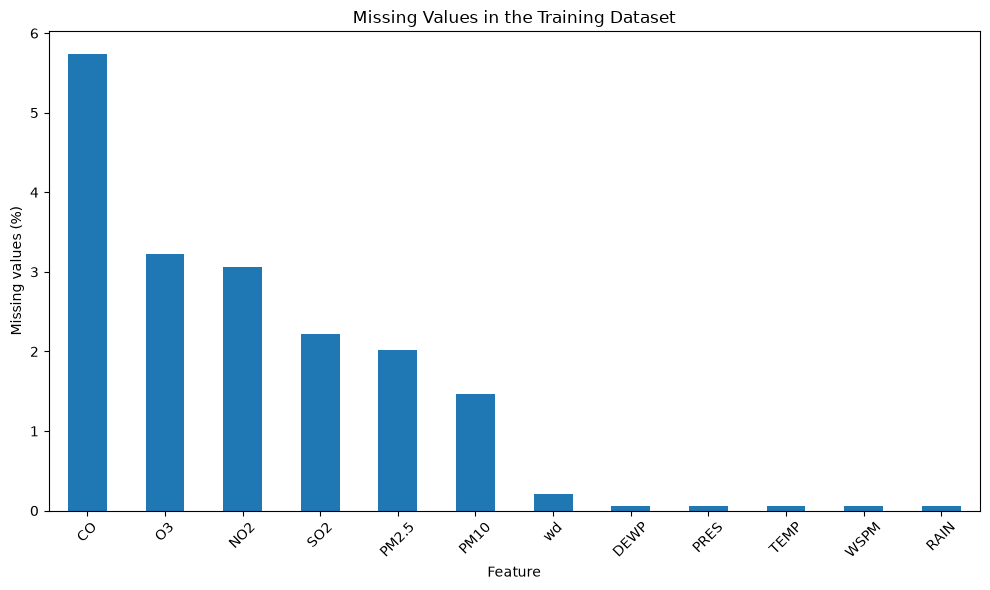

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

missing_summary["missing_percent"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Missing Values in the Training Dataset")
ax.set_xlabel("Feature")
ax.set_ylabel("Missing values (%)")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "01_missing_values_overall.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
station,,,,,,,,,,,,
Aotizhongxin,2.836,2.296,3.022,3.091,6.182,5.543,0.008,0.008,0.008,0.008,0.038,0.008
Changping,2.509,1.844,1.855,2.072,5.216,1.867,0.125,0.125,0.125,0.129,0.281,0.122
Dingling,1.886,1.863,2.019,3.996,6.710,2.866,0.125,0.125,0.125,0.129,0.281,0.122
Dongsi,1.410,0.912,1.319,4.832,10.831,1.243,0.008,0.008,0.008,0.008,0.027,0.008
Guanyuan,1.620,1.102,1.426,2.125,5.828,4.041,0.008,0.008,0.008,0.008,0.038,0.008
Gucheng,1.867,1.057,1.574,2.007,4.851,2.406,0.129,0.125,0.129,0.099,0.452,0.118
Huairou,3.098,2.456,3.186,4.923,4.585,3.722,0.125,0.133,0.133,0.137,0.540,0.141
Nongzhanguan,1.848,1.255,1.285,1.973,3.680,1.479,0.008,0.008,0.008,0.008,0.027,0.008
Shunyi,2.232,1.053,3.311,3.532,6.668,2.194,0.125,0.125,0.137,0.125,0.757,0.125


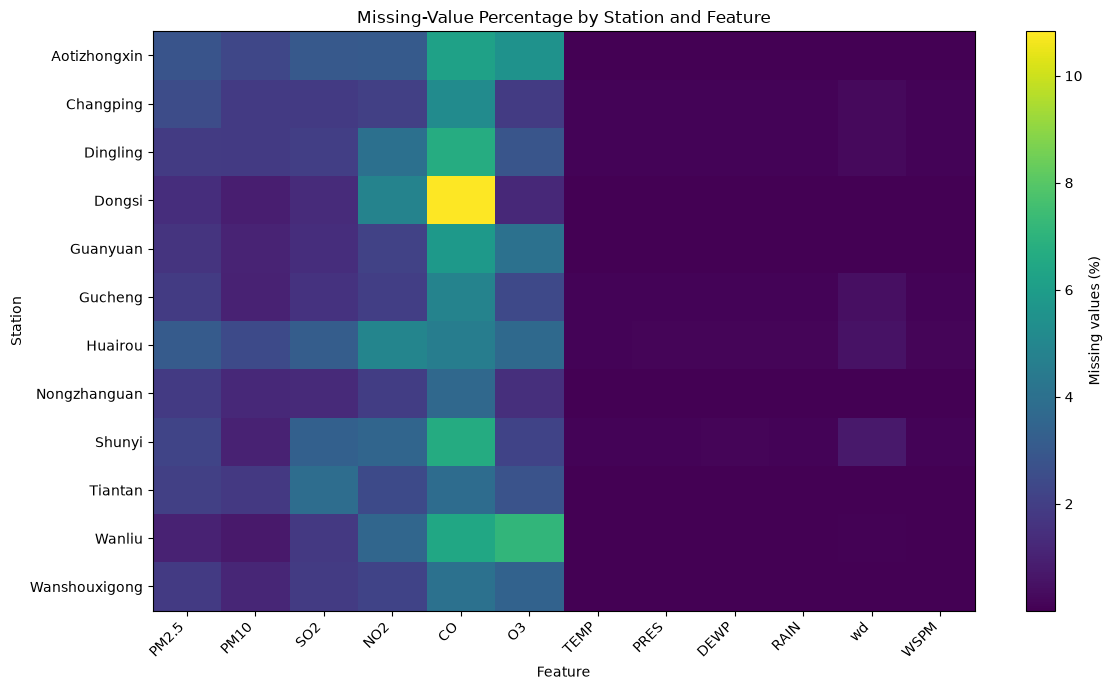

In [10]:
MODEL_FEATURES = POLLUTANT_COLUMNS + WEATHER_COLUMNS

missing_by_station = (
    train
    .set_index(STATION_COLUMN)[MODEL_FEATURES]
    .isna()
    .groupby(level=0)
    .mean()
    .mul(100)
)

display(missing_by_station.round(3))

# Save in a CSV

missing_by_station.to_csv(
    METRICS_DIR / "data_audit_missing_values_by_station.csv"
)

# Plot in a heatmap

fig, ax = plt.subplots(figsize=(12, 7))

image = ax.imshow(
    missing_by_station.to_numpy(),
    aspect="auto",
)

ax.set_title("Missing-Value Percentage by Station and Feature")
ax.set_xlabel("Feature")
ax.set_ylabel("Station")

ax.set_xticks(
    range(len(missing_by_station.columns)),
    labels=missing_by_station.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(missing_by_station.index)),
    labels=missing_by_station.index,
)

fig.colorbar(
    image,
    ax=ax,
    label="Missing values (%)",
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "02_missing_values_by_station.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [11]:
rows_with_missing = train_raw.isna().any(axis=1)

print(
    "Rows with at least one missing value:",
    int(rows_with_missing.sum()),
)

print(
    "Percentage of rows with at least one missing value:",
    f"{rows_with_missing.mean() * 100:.3f}%",
)

Rows with at least one missing value: 31431
Percentage of rows with at least one missing value: 9.958%


In [12]:
pm25 = train[TARGET_COLUMN].dropna()

target_summary = pm25.describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

display(target_summary.to_frame(name="PM2.5"))

# Save in a CSV

target_summary.to_csv(
    METRICS_DIR / "data_audit_pm25_summary.csv",
    header=["PM2.5"],
)

,PM2.5
count,"309,276.000"
mean,80.362
std,80.169
min,2.000
1%,3.000
5%,6.000
10%,9.000
25%,21.000
50%,56.000
75%,113.000


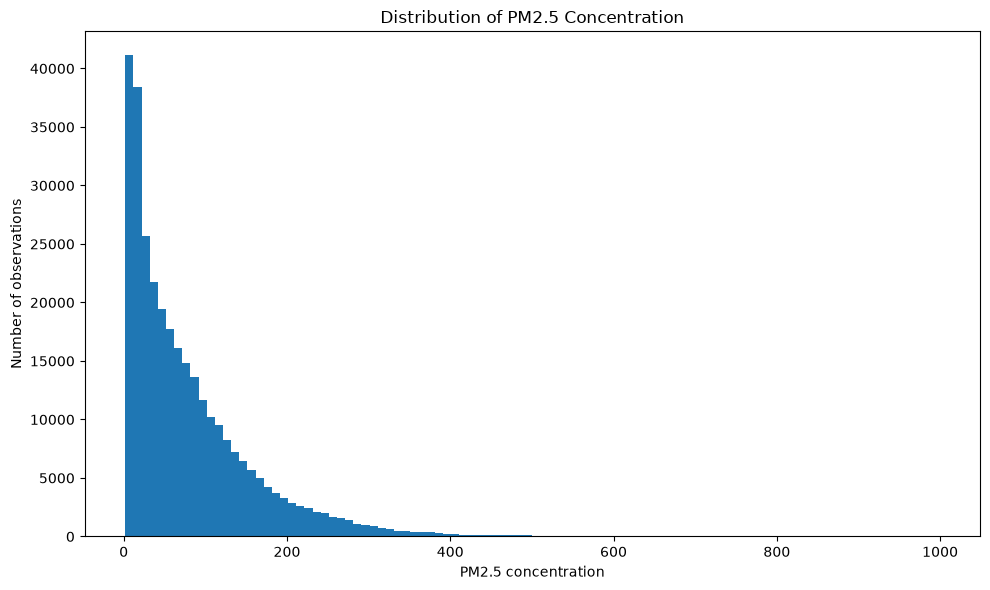

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    pm25,
    bins=100,
)

ax.set_title("Distribution of PM2.5 Concentration")
ax.set_xlabel("PM2.5 concentration")
ax.set_ylabel("Number of observations")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "03_pm25_distribution_full.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

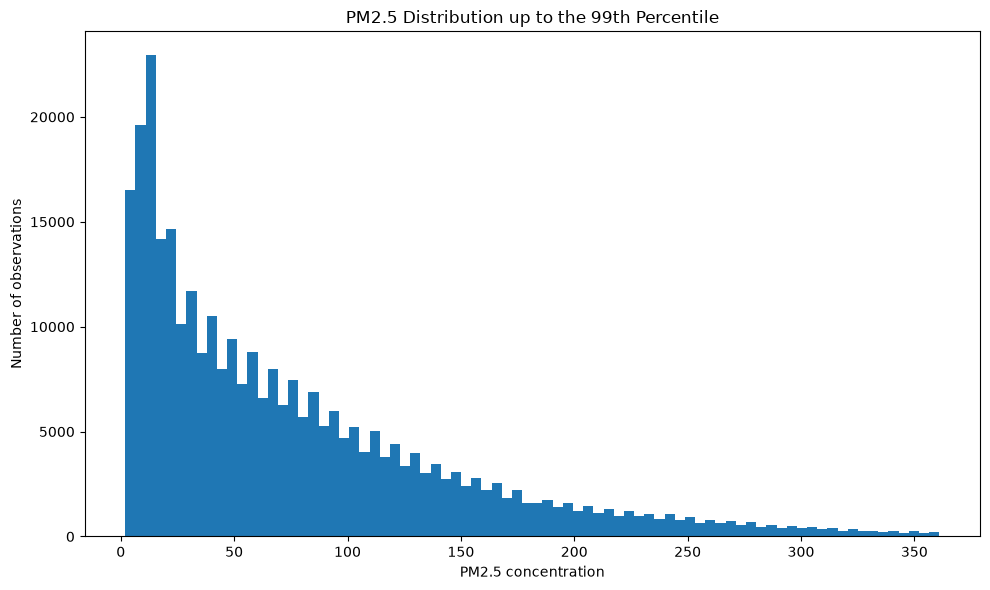

99th percentile: 361.000


In [14]:
pm25_99th_percentile = pm25.quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    pm25[pm25 <= pm25_99th_percentile],
    bins=80,
)

ax.set_title(
    "PM2.5 Distribution up to the 99th Percentile"
)
ax.set_xlabel("PM2.5 concentration")
ax.set_ylabel("Number of observations")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "04_pm25_distribution_99_percent.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "99th percentile:",
    f"{pm25_99th_percentile:.3f}",
)

In [15]:
station_pm25_summary = (
    train
    .groupby(STATION_COLUMN)[TARGET_COLUMN]
    .agg(
        valid_count="count",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
    )
    .sort_values("mean", ascending=False)
)

display(station_pm25_summary.round(3))

# Save in a CSV

station_pm25_summary.to_csv(
    METRICS_DIR / "data_audit_pm25_by_station.csv"
)

,valid_count,mean,median,standard_deviation,minimum,maximum
station,,,,,,
Dongsi,25933,85.584,61.000,85.081,3.000,737.000
Nongzhanguan,25818,85.350,60.000,85.915,3.000,844.000
Wanliu,26033,85.247,61.000,81.915,3.000,957.000
Wanshouxigong,25820,84.746,61.000,84.507,3.000,999.000
Gucheng,25813,83.756,60.000,80.726,2.000,770.000
Aotizhongxin,25558,83.587,60.000,81.524,3.000,898.000
Guanyuan,25878,82.766,60.000,79.843,3.000,680.000
Tiantan,25765,82.746,60.000,80.293,3.000,821.000
Shunyi,25717,80.080,56.000,80.472,3.000,941.000


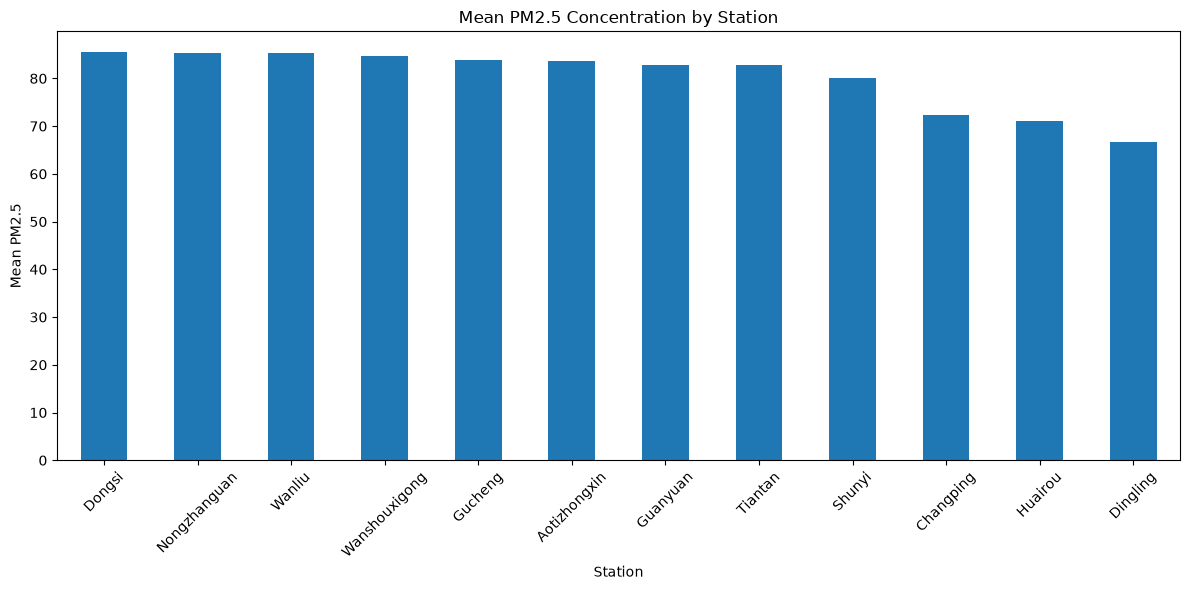

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

station_pm25_summary["mean"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Mean PM2.5 Concentration by Station")
ax.set_xlabel("Station")
ax.set_ylabel("Mean PM2.5")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "05_mean_pm25_by_station.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

,mean,median
hour,,
0,88.105,64.000
1,87.030,62.000
2,84.950,61.000
3,82.562,60.000
4,79.922,58.000
5,76.801,55.000
6,74.777,53.000
7,73.939,53.000
8,75.419,53.000


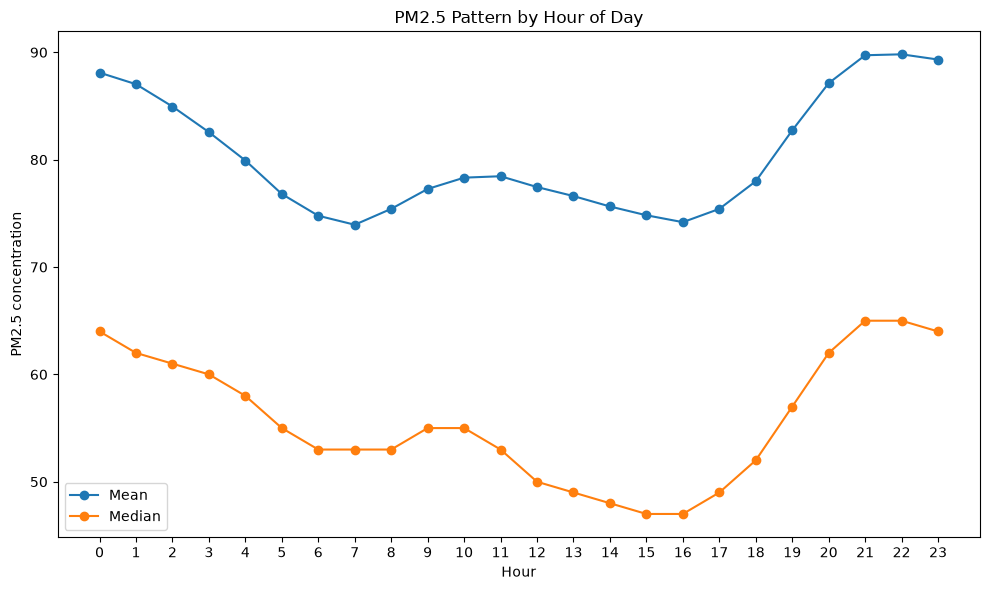

In [17]:
hourly_pm25 = (
    train
    .groupby("hour")[TARGET_COLUMN]
    .agg(
        mean="mean",
        median="median",
    )
)

display(hourly_pm25)

# Plot Hour-of-day pattern

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    hourly_pm25.index,
    hourly_pm25["mean"],
    marker="o",
    label="Mean",
)

ax.plot(
    hourly_pm25.index,
    hourly_pm25["median"],
    marker="o",
    label="Median",
)

ax.set_title("PM2.5 Pattern by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("PM2.5 concentration")
ax.set_xticks(range(24))
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "06_pm25_by_hour.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

,mean,median
month_start,,
2013-03-01,104.888,85.000
2013-04-01,62.139,50.000
2013-05-01,81.846,69.000
2013-06-01,102.444,91.000
2013-07-01,67.909,52.000


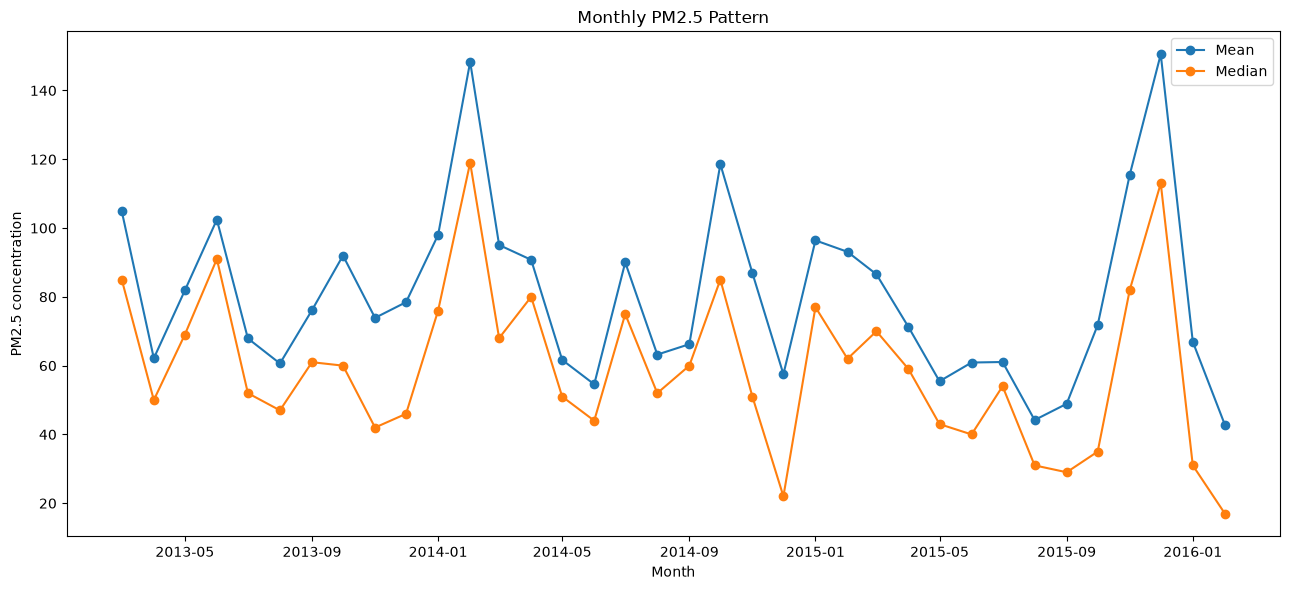

In [18]:
train["month_start"] = (
    train["datetime"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_pm25 = (
    train
    .groupby("month_start")[TARGET_COLUMN]
    .agg(
        mean="mean",
        median="median",
    )
)

display(monthly_pm25.head())

# Plot monthly time-series pattern

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    monthly_pm25.index,
    monthly_pm25["mean"],
    marker="o",
    label="Mean",
)

ax.plot(
    monthly_pm25.index,
    monthly_pm25["median"],
    marker="o",
    label="Median",
)

ax.set_title("Monthly PM2.5 Pattern")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 concentration")
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "07_monthly_pm25_pattern.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

,mean,median
month,,
1,87.062,62.000
2,93.537,50.000
3,95.536,74.000
4,74.613,63.000
5,66.262,54.000
6,72.615,54.000
7,72.953,58.000
8,56.041,42.000
9,63.844,50.000


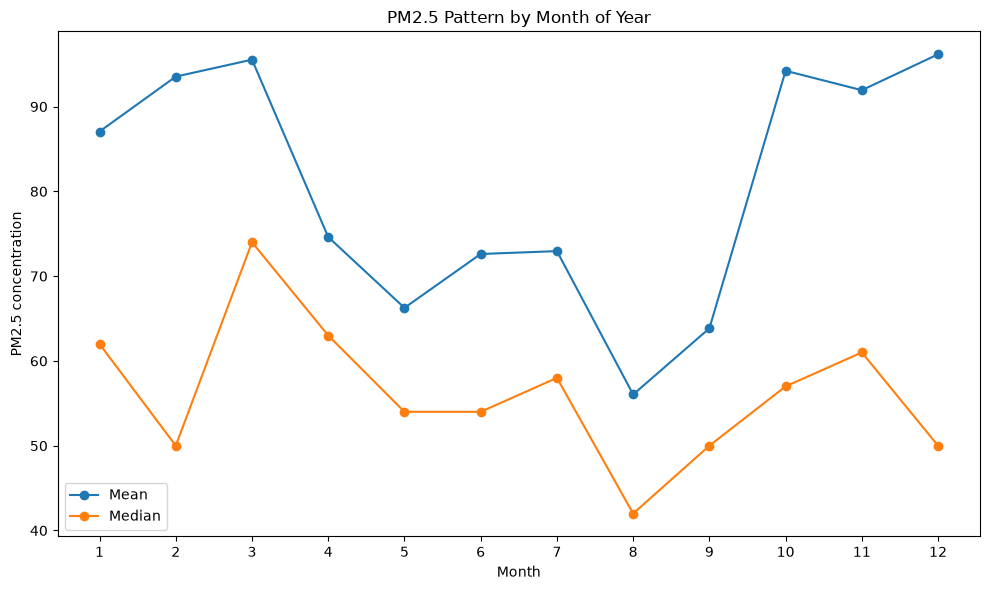

In [19]:
month_of_year_pm25 = (
    train
    .groupby("month")[TARGET_COLUMN]
    .agg(
        mean="mean",
        median="median",
    )
)

display(month_of_year_pm25)

# Plot month-of-year pattern

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    month_of_year_pm25.index,
    month_of_year_pm25["mean"],
    marker="o",
    label="Mean",
)

ax.plot(
    month_of_year_pm25.index,
    month_of_year_pm25["median"],
    marker="o",
    label="Median",
)

ax.set_title("PM2.5 Pattern by Month of Year")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 concentration")
ax.set_xticks(range(1, 13))
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "08_pm25_by_month.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

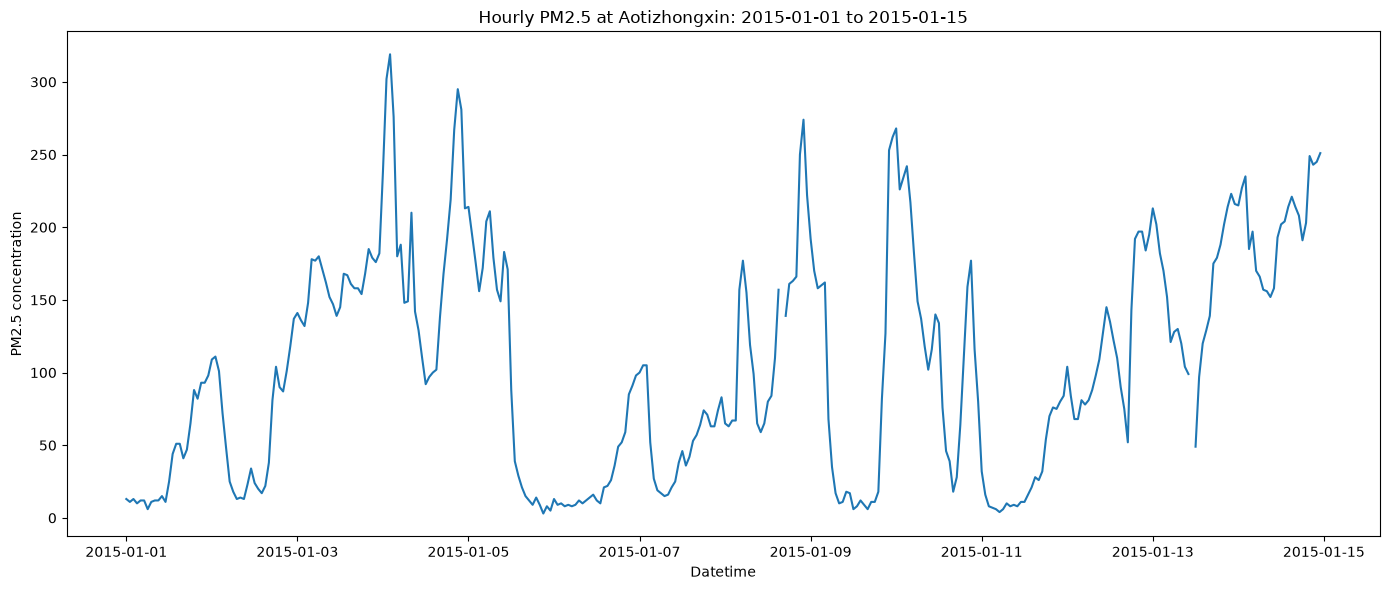

In [20]:
EXAMPLE_STATION = "Aotizhongxin"
EXAMPLE_START = pd.Timestamp("2015-01-01")
EXAMPLE_END = pd.Timestamp("2015-01-15")

example_data = train.loc[
    (train[STATION_COLUMN] == EXAMPLE_STATION)
    & (train["datetime"] >= EXAMPLE_START)
    & (train["datetime"] < EXAMPLE_END),
    ["datetime", TARGET_COLUMN],
]

# Plot example station time series

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    example_data["datetime"],
    example_data[TARGET_COLUMN],
)

ax.set_title(
    f"Hourly PM2.5 at {EXAMPLE_STATION}: "
    f"{EXAMPLE_START.date()} to {EXAMPLE_END.date()}"
)
ax.set_xlabel("Datetime")
ax.set_ylabel("PM2.5 concentration")

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "09_example_station_pm25_series.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [21]:
NUMERICAL_MODEL_FEATURES = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM",
]

numerical_summary = (
    train[NUMERICAL_MODEL_FEATURES]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .transpose()
)

display(numerical_summary)

# Save in a CSV

numerical_summary.to_csv(
    METRICS_DIR / "data_audit_numerical_summary.csv"
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
PM2.5,"309,276.000",80.362,80.169,2.000,3.000,6.000,21.000,56.000,113.000,242.000,361.000,999.000
PM10,"311,033.000",105.668,91.024,2.000,5.000,10.000,36.000,84.000,148.000,278.000,413.000,999.000
SO2,"308,661.000",17.811,23.513,0.286,1.000,2.000,3.000,9.000,22.000,67.000,111.000,500.000
NO2,"305,989.000",51.242,35.003,1.026,3.000,8.000,24.000,44.000,72.000,117.000,156.003,290.000
CO,"297,542.000","1,242.387","1,134.971",100.000,100.000,200.000,500.000,900.000,"1,600.000","3,500.000","5,800.000","10,000.000"
O3,"305,471.000",57.278,56.635,0.214,1.000,2.000,11.000,45.000,82.000,176.000,244.580,"1,071.000"
TEMP,"315,469.000",13.392,11.447,-19.900,-8.100,-4.500,3.000,14.400,23.100,30.500,33.900,41.600
PRES,"315,468.000","1,010.645",10.468,982.400,990.100,994.400,"1,002.200","1,010.300","1,019.000","1,027.600","1,032.400","1,042.800"
DEWP,"315,464.000",2.409,13.859,-43.400,-25.200,-20.100,-9.100,3.000,15.200,21.900,24.300,29.100
RAIN,"315,472.000",0.061,0.795,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.200,72.500


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
PM2.5,1.000,0.873,0.499,0.650,0.778,-0.137,-0.106,0.010,0.138,-0.006,-0.267
PM10,0.873,1.000,0.474,0.640,0.684,-0.089,-0.060,-0.036,0.099,-0.019,-0.175
SO2,0.499,0.474,1.000,0.518,0.580,-0.172,-0.327,0.233,-0.271,-0.039,-0.103
NO2,0.650,0.640,0.518,1.000,0.691,-0.462,-0.249,0.157,-0.009,-0.039,-0.391
CO,0.778,0.684,0.580,0.691,1.000,-0.310,-0.316,0.184,-0.051,-0.007,-0.291
O3,-0.137,-0.089,-0.172,-0.462,-0.310,1.000,0.591,-0.451,0.317,0.030,0.275
TEMP,-0.106,-0.060,-0.327,-0.249,-0.316,0.591,1.000,-0.812,0.823,0.036,0.014
PRES,0.010,-0.036,0.233,0.157,0.184,-0.451,-0.812,1.000,-0.747,-0.056,0.080
DEWP,0.138,0.099,-0.271,-0.009,-0.051,0.317,0.823,-0.747,1.000,0.083,-0.310
RAIN,-0.006,-0.019,-0.039,-0.039,-0.007,0.030,0.036,-0.056,0.083,1.000,0.006


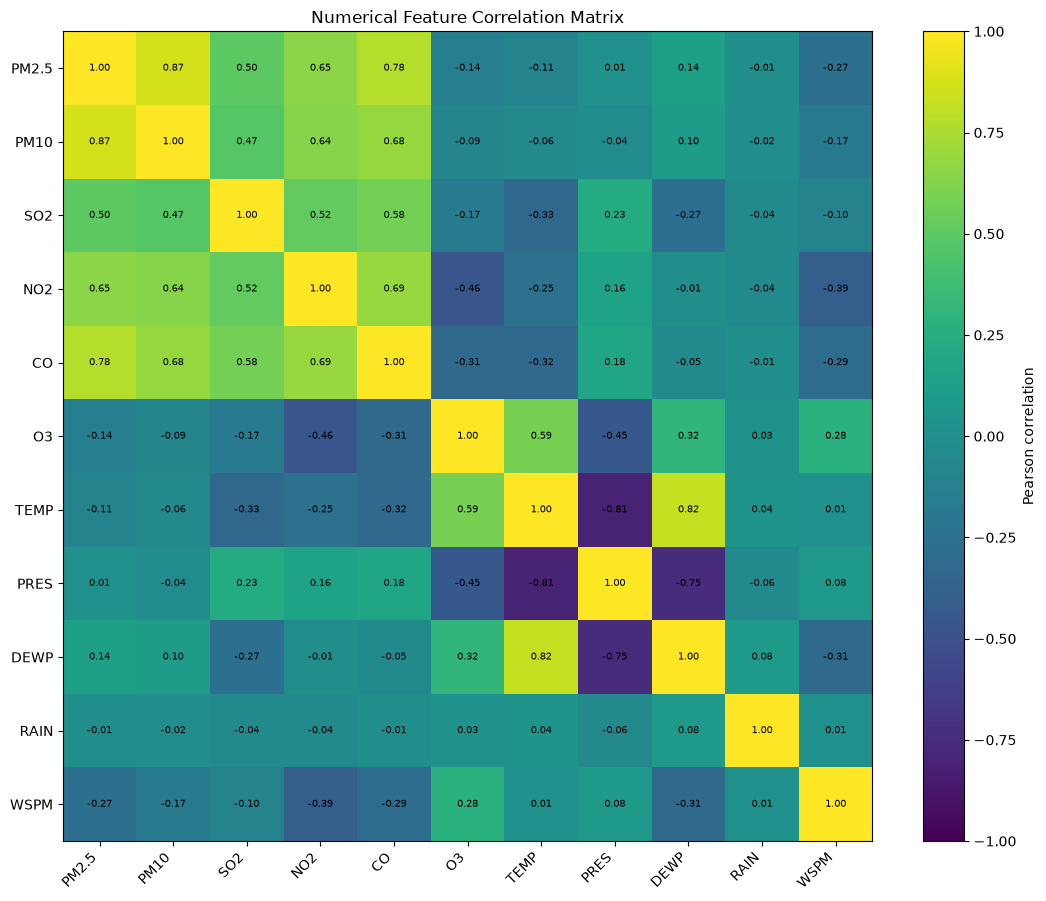

In [22]:
correlation_matrix = (
    train[NUMERICAL_MODEL_FEATURES]
    .corr()
)

display(correlation_matrix.round(3))

# Save in a CSV

correlation_matrix.to_csv(
    METRICS_DIR / "data_audit_correlation_matrix.csv"
)

# Plot the Correlation matrix

fig, ax = plt.subplots(figsize=(11, 9))

image = ax.imshow(
    correlation_matrix.to_numpy(),
    vmin=-1,
    vmax=1,
)

ax.set_title("Numerical Feature Correlation Matrix")

ax.set_xticks(
    range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    range(len(correlation_matrix.index)),
    labels=correlation_matrix.index,
)

for row_index in range(len(correlation_matrix.index)):
    for column_index in range(
        len(correlation_matrix.columns)
    ):
        value = correlation_matrix.iloc[
            row_index,
            column_index,
        ]

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

fig.colorbar(
    image,
    ax=ax,
    label="Pearson correlation",
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "10_feature_correlation_matrix.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [23]:
wind_direction_summary = (
    train["wd"]
    .value_counts(
        dropna=False,
    )
    .rename_axis("wind_direction")
    .reset_index(name="count")
)

wind_direction_summary["percentage"] = (
    wind_direction_summary["count"]
    / len(train)
    * 100
)

display(wind_direction_summary)

# Save in a CSV

wind_direction_summary.to_csv(
    METRICS_DIR / "data_audit_wind_direction.csv",
    index=False,
)

,wind_direction,count,percentage
0,NE,30089,9.532
1,ENE,26371,8.355
2,N,24236,7.678
3,E,23339,7.394
4,NW,22778,7.216
5,SW,21005,6.655
6,NNE,20766,6.579
7,WNW,19928,6.313
8,NNW,18748,5.940
9,ESE,18348,5.813


In [24]:
VALIDATION_START = pd.Timestamp(
    "2015-09-01 00:00:00"
)

LOCAL_TEST_START = pd.Timestamp(
    "2015-12-01 00:00:00"
)

train["split"] = "local_test"

train.loc[
    train["datetime"] < LOCAL_TEST_START,
    "split",
] = "validation"

train.loc[
    train["datetime"] < VALIDATION_START,
    "split",
] = "train"

train["split"] = pd.Categorical(
    train["split"],
    categories=[
        "train",
        "validation",
        "local_test",
    ],
    ordered=True,
)

In [25]:
train["has_any_missing_feature"] = (
    train[MODEL_FEATURES]
    .isna()
    .any(axis=1)
)

split_summary = (
    train
    .groupby(
        "split",
        observed=True,
    )
    .agg(
        rows=("datetime", "size"),
        start_datetime=("datetime", "min"),
        end_datetime=("datetime", "max"),
        stations=(STATION_COLUMN, "nunique"),
        valid_pm25_targets=(TARGET_COLUMN, "count"),
        rows_with_missing_features=(
            "has_any_missing_feature",
            "sum",
        ),
    )
)

split_summary["missing_pm25_targets"] = (
    split_summary["rows"]
    - split_summary["valid_pm25_targets"]
)

display(split_summary)

# Save in a CSV

split_summary.to_csv(
    METRICS_DIR / "data_audit_split_summary.csv"
)

,rows,start_datetime,end_datetime,stations,valid_pm25_targets,rows_with_missing_features,missing_pm25_targets
split,,,,,,,
train,263232,2013-03-01,2015-08-31 23:00:00,12,257927,28922,5305
validation,26208,2015-09-01,2015-11-30 23:00:00,12,25458,1519,750
local_test,26208,2015-12-01,2016-02-29 23:00:00,12,25891,990,317


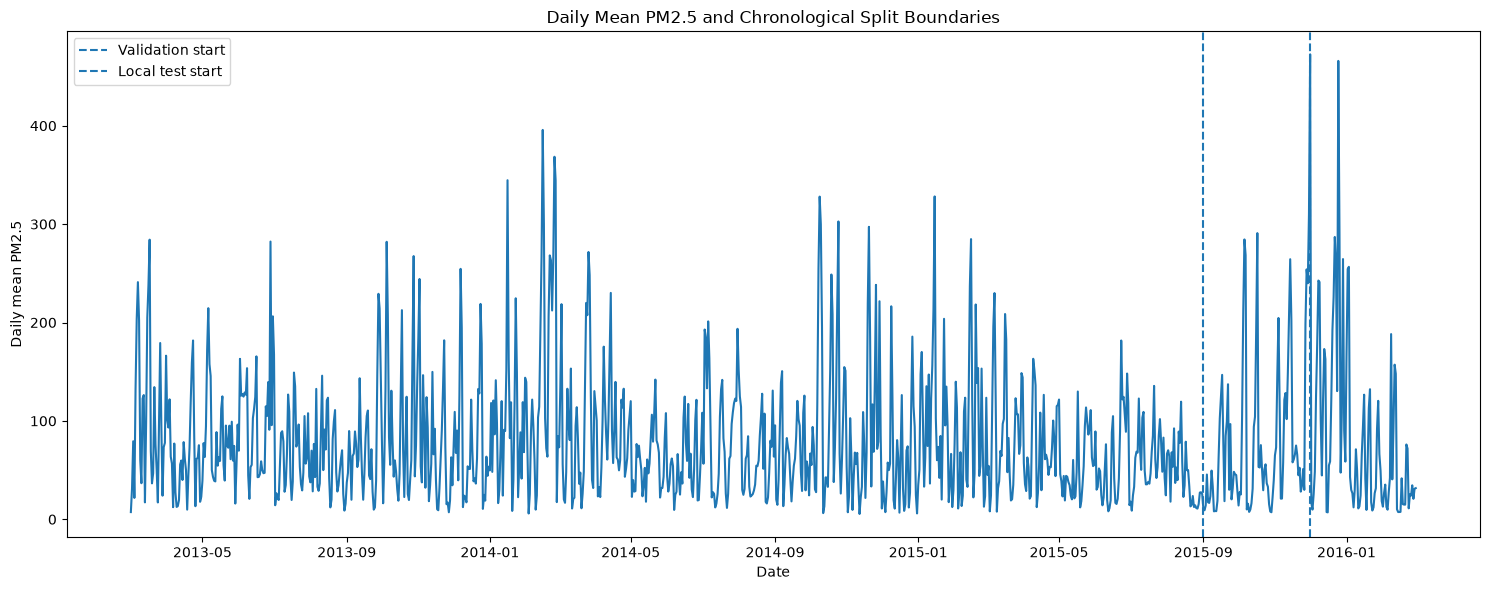

In [26]:
daily_pm25 = (
    train
    .set_index("datetime")
    .groupby(
        pd.Grouper(freq="D"),
        observed=True,
    )[TARGET_COLUMN]
    .mean()
)

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    daily_pm25.index,
    daily_pm25.values,
)

ax.axvline(
    VALIDATION_START,
    linestyle="--",
    label="Validation start",
)

ax.axvline(
    LOCAL_TEST_START,
    linestyle="--",
    label="Local test start",
)

ax.set_title(
    "Daily Mean PM2.5 and Chronological Split Boundaries"
)
ax.set_xlabel("Date")
ax.set_ylabel("Daily mean PM2.5")
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "11_chronological_split.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [27]:
audit_metadata = {
    "dataset": {
        "rows": int(len(train)),
        "raw_columns": int(train_raw.shape[1]),
        "stations": int(
            train[STATION_COLUMN].nunique()
        ),
        "start_datetime": str(
            train["datetime"].min()
        ),
        "end_datetime": str(
            train["datetime"].max()
        ),
        "duplicate_station_timestamps": duplicate_count,
        "timestamp_gaps": int(
            continuity_summary[
                "non_hourly_intervals"
            ].sum()
        ),
    },
    "target": {
        "name": TARGET_COLUMN,
        "valid_values": int(pm25.count()),
        "missing_values": int(
            train[TARGET_COLUMN].isna().sum()
        ),
        "mean": float(pm25.mean()),
        "median": float(pm25.median()),
        "minimum": float(pm25.min()),
        "maximum": float(pm25.max()),
    },
    "split_boundaries": {
        "validation_start": str(VALIDATION_START),
        "local_test_start": str(LOCAL_TEST_START),
    },
}

metadata_path = (
    METRICS_DIR
    / "data_audit_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        audit_metadata,
        file,
        indent=2,
    )

print(f"Saved metadata to: {metadata_path}")

Saved metadata to: C:\Users\wijer\Documents\GitHub\co-5420-air-pollution\results\metrics\data_audit_metadata.json


## Data-audit conclusions

### Dataset structure

- The training dataset contains 315,648 hourly rows from 12 monitoring stations.
- Each station has a continuous hourly timeline from 1 March 2013 to 29 February 2016.
- No duplicated station-timestamp records were found.
- Input windows must be constructed separately within each station.

### Missing values

- Missing values occur in both pollutant and meteorological variables.
- CO has the highest missing percentage.
- PM2.5 also contains missing values, including missing future targets.
- Entire incomplete rows will not be deleted because this would remove a substantial amount of data and break temporal continuity.
- A causal station-aware imputation strategy will be developed in the preprocessing stage.

### PM2.5 target

- PM2.5 is strongly right-skewed.
- Severe-pollution observations must not be removed simply because they are large.
- Both RMSE and MAE should be reported because RMSE gives greater weight to large errors.
- Station-level and high-pollution error analysis will be required.

### Features

- Numerical variables have significantly different scales, so training-only scaling will be required.
- Station identity should be included because pollution behaviour differs by monitoring site.
- Hour and seasonal information should use cyclical encoding.
- Wind direction requires categorical or circular encoding.

### Validation design

- A random row split will not be used.
- The preliminary chronological split is:
  - training: before 1 September 2015;
  - validation: 1 September to 30 November 2015;
  - local test: 1 December 2015 to 29 February 2016.
- Imputation statistics, encoders, and scalers must be fitted using the training split only.
- Split membership will be determined using the prediction target timestamp.

In [28]:
required_outputs = [
    METRICS_DIR / "data_audit_column_summary.csv",
    METRICS_DIR / "data_audit_missing_values.csv",
    METRICS_DIR / "data_audit_missing_values_by_station.csv",
    METRICS_DIR / "data_audit_pm25_summary.csv",
    METRICS_DIR / "data_audit_pm25_by_station.csv",
    METRICS_DIR / "data_audit_numerical_summary.csv",
    METRICS_DIR / "data_audit_correlation_matrix.csv",
    METRICS_DIR / "data_audit_wind_direction.csv",
    METRICS_DIR / "data_audit_split_summary.csv",
    METRICS_DIR / "data_audit_metadata.json",
]

missing_outputs = [
    path
    for path in required_outputs
    if not path.exists()
]

assert not missing_outputs, (
    "Missing audit outputs:\n"
    + "\n".join(
        str(path)
        for path in missing_outputs
    )
)

print("=" * 60)
print("DATA AUDIT COMPLETED SUCCESSFULLY")
print("=" * 60)

DATA AUDIT COMPLETED SUCCESSFULLY
